In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [20]:
df2 = pd.read_csv(r'C:\Users\prati\Desktop\BITSOM\q2_customers.csv')

In [21]:
print("Shape:", df2.shape)
print("\nFirst 5 rows:")
print(df2.head())
print("\nMissing values:")
print(df2.isnull().sum())

Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


In [22]:
scaler2 = StandardScaler()
X2 = scaler2.fit_transform(df2)

In [23]:
print("\nScaling done! Shape:", X2.shape)


Scaling done! Shape: (500, 6)


# Why Scaling is Essential Before K-Means

K-Means clustering works by computing Euclidean distances between data points 
and cluster centroids. If features have different scales (e.g., `annual_spend` in 
thousands vs `visits_per_month` in single digits), the feature with the larger range 
will dominate the distance calculation and bias the clustering result.

StandardScaler transforms all features to have mean = 0 and standard deviation = 1, 
ensuring every feature contributes equally to the distance computation.

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [25]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X2)
    wcss.append(km.inertia_)

C:\Users\prati\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\prati\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\prati\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\prati\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

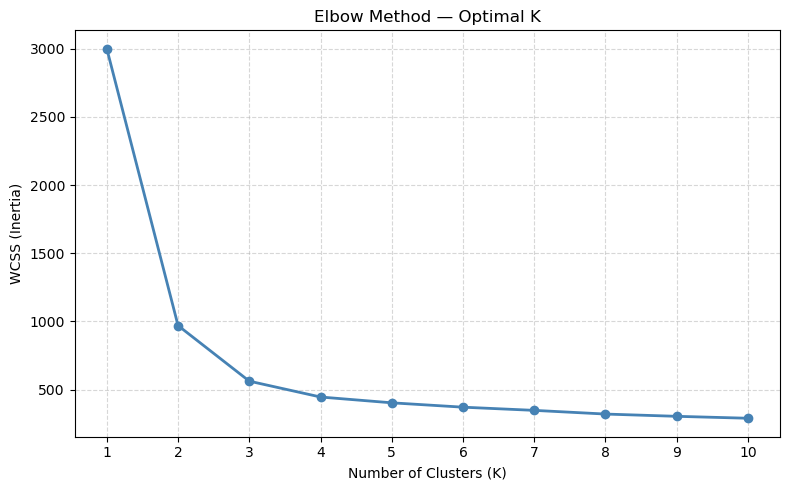

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Choosing Optimal K

From the elbow plot, the WCSS drops sharply from K=1 to K=3. After K=3, the 
rate of decrease slows down significantly and the curve begins to flatten out. 
The "elbow" point is clearly at K=3, meaning adding more clusters beyond 3 
gives diminishing returns in reducing within-cluster variance.

Therefore, K=3 is selected as the optimal number of clusters.

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X2)

C:\Users\prati\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [28]:
df2['cluster'] = kmeans.labels_

In [29]:
centroids = pd.DataFrame(
    scaler2.inverse_transform(kmeans.cluster_centers_),
    columns=df2.columns[:-1]
)
centroids.index.name = 'cluster'
print("Cluster Centroids:")
print(centroids.round(2))

Cluster Centroids:
           age  annual_spend  visits_per_month  basket_size  \
cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


In [30]:
print("\nCluster Sizes:")
print(df2['cluster'].value_counts().sort_index())


Cluster Sizes:
cluster
0    170
1    165
2    165
Name: count, dtype: int64


## Cluster Interpretation (Business Terms)

Cluster 0 — Young Frequent Low-Spenders (170 customers)
Young customers (~25 years), visit very frequently (14x/month) and were seen 
recently (9 days ago), but spend very little (₹14,847/year) with small basket 
sizes and few product categories. These are likely budget-conscious young shoppers.

Cluster 1 — Older High-Value Inactive Customers (165 customers)
Older customers (~57 years) with the highest annual spend (₹89,413) and largest 
basket sizes, but visit rarely (2.5x/month) and haven't visited in 105 days. 
These are high-value but at-risk customers who need re-engagement campaigns.

Cluster 2 — Middle-aged Moderate Customers (165 customers)
Middle-aged customers (~40 years) with moderate spend (₹43,340), moderate visit 
frequency (8x/month), and average basket size.

In [31]:
from sklearn.decomposition import PCA

In [32]:
pca = PCA(n_components=2, random_state=42)
X2_pca = pca.fit_transform(X2)

In [33]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_.round(4))
print("Total Variance Explained:", round(pca.explained_variance_ratio_.sum(), 4))


Explained Variance Ratio: [0.8356 0.0557]
Total Variance Explained: 0.8913


In [34]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df2.columns[:-1],
    columns=['PC1', 'PC2']
)

In [35]:
print("\nFeature Loadings:")
print(loadings.round(4))


Feature Loadings:
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


# PCA Interpretation

PC1 (83.56% variance explained):
PC1 has strong positive loadings from `age` (0.41), `annual_spend` (0.42), 
`basket_size` (0.41), and `num_categories_purchased` (0.41), and a strong 
negative loading from `visits_per_month` (-0.41). This means PC1 captures 
spending power and age — high PC1 = older, high-spending, infrequent visitors. 
Low PC1 = younger, low-spending, frequent visitors.

PC2 (5.57% variance explained):
PC2 is dominated by `days_since_last_visit` (0.91), meaning it captures 
recency of visit. High PC2 = customers who haven't visited in a long time 
(inactive). Low PC2 = recently active customers.

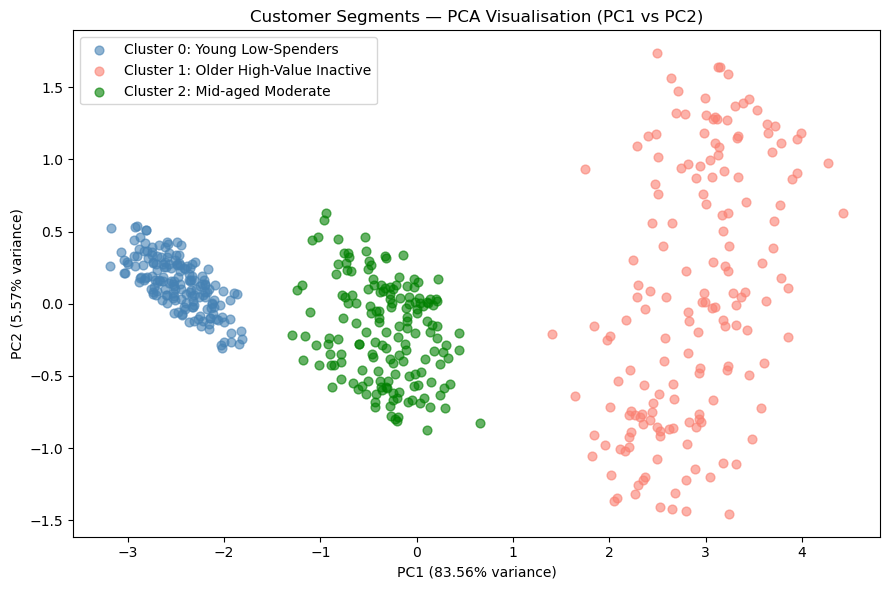

In [41]:
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'salmon', 'green']
labels = ['Cluster 0: Young Low-Spenders',
          'Cluster 1: Older High-Value Inactive',
          'Cluster 2: Mid-aged Moderate']
for i in range(3):
    mask = df2['cluster'] == i
    plt.scatter(
        X2_pca[mask, 0], X2_pca[mask, 1],
        c=colors[i], label=labels[i], alpha=0.6, s=40
    )
    plt.title('Customer Segments — PCA Visualisation (PC1 vs PC2)')
plt.xlabel('PC1 (83.56% variance)')
plt.ylabel('PC2 (5.57% variance)')
plt.legend()
plt.tight_layout()
plt.show()